In [47]:
# Embeddings are here to make the meaning of sectance moree clear 
# and understandalbe to the model.
# but this is achived by the BERT contenxtua lmodels which are context based embeddings .
# where as the glove methods like CBOW. and skip grm are not contet based embeddings and they are statics and cant deiffrer 
#bettween the money bank and river bank

In [ ]:
import tiktoken as tk

text = "Practicing the embedding and maknig vectors and how they are fomed and visuvalization"

encoding = tk.get_encoding("cl100k_base")

tokens = encoding.encode(text)
print(tokens)
len(tokens)

In [1]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

sentences = [
    "I love cats.",
    "Artificial intelligence is changing the world.",
    "unbelievable",
    "https://example.com/products",
    "2026",
    "Hello!!!"
]

embeddings = model.encode(sentences)

print(embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

(6, 384)


In [3]:
# checking with each embedding 

embedding = embeddings[0]

print(embedding)
len(embedding)

[ 6.35464936e-02 -1.16455369e-02  8.68439823e-02  4.78410767e-03
 -7.28632584e-02 -2.70671025e-02  6.03809096e-02  5.61292889e-03
  2.42770407e-02  3.85653004e-02 -4.36340412e-03 -1.14263212e-02
 -3.45137827e-02  5.40756620e-02  2.66370550e-02 -2.20423397e-02
 -5.26472963e-02 -2.76584290e-02 -3.82926539e-02  3.60538699e-02
 -1.19695872e-01  4.38118502e-02  2.67203655e-02 -1.04640913e-03
 -7.22042695e-02  3.76284607e-02 -3.82643417e-02 -5.72798178e-02
 -5.18502146e-02  3.04010842e-04 -4.67888899e-02  4.45002988e-02
 -2.84053646e-02  4.14401293e-02 -5.59243150e-02 -5.01138344e-03
  8.50224588e-03 -8.60887207e-03  5.04359305e-02  8.29478428e-02
 -3.79533358e-02  3.02971923e-04  4.31413502e-02  1.77483521e-02
 -8.71123374e-02 -2.92401761e-02  2.53341882e-03 -8.53576139e-02
  8.19269046e-02  3.99442948e-03  3.20457928e-02  5.15032150e-02
 -3.46309468e-02 -2.32874253e-03  1.55282468e-02 -2.44954396e-02
  6.90355226e-02 -4.01254185e-02 -3.66776101e-02 -5.75932562e-02
  4.85219024e-02  1.23620

384

In [4]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(
    [embeddings[0]],
    [embeddings[1]]
)

print(similarity)

[[0.07025853]]


In [5]:
similarity_matrix = cosine_similarity(embeddings)

print(similarity_matrix)

[[ 1.          0.07025856  0.09525385  0.04750545 -0.00303168  0.17878944]
 [ 0.07025856  1.0000002   0.10129549  0.04150463  0.26807392  0.0201771 ]
 [ 0.09525385  0.10129549  1.0000002   0.09992924  0.2050553   0.10933208]
 [ 0.04750545  0.04150463  0.09992924  1.0000001   0.04811567  0.02780527]
 [-0.00303168  0.26807392  0.2050553   0.04811567  1.0000002   0.11669531]
 [ 0.17878944  0.0201771   0.10933208  0.02780527  0.11669531  1.        ]]


In [ ]:
# so it is makng the process like get the context and make the tokens and then ids from the ids we make the embeddings

In [10]:
# Lets make th embedding and make the semantic searches

documents = [
    "Python is a programming language.",
    "Java is widely used for software development.",
    "Machine learning uses algorithms to learn patterns.",
    "Deep learning uses neural networks.",
    "The capital of France is Paris.",
    "Football is a popular sport."
]

In [15]:
doc_embeddings = model.encode(documents)

print(doc_embeddings.shape)

(6, 384)


In [ ]:
# now we made somethng like a small model but not a modle like 
# we just create some text from the embedings and , whe nwe give some query it
# match te similarity and then choose which text suits it mostly and showed as per ranking which mathvih percentage way.

In [22]:
query = "How can I learn programming?"
query_embedding = model.encode([query])

scores = cosine_similarity(
    query_embedding,
    doc_embeddings
)[0]

results = sorted(
    zip(documents, scores),
    key=lambda x: x[1],
    reverse=True
)

for document, score in results:
    print(f"{score:.4f} -> {document}")

0.4028 -> Python is a programming language.
0.3168 -> Java is widely used for software development.
0.2806 -> Machine learning uses algorithms to learn patterns.
0.1656 -> Deep learning uses neural networks.
0.0259 -> The capital of France is Paris.
0.0159 -> Football is a popular sport.


In [23]:
# smae as cosine_similarity which is used most of the time we have euclidean distance method also so 

from sklearn.metrics import pairwise_distances

distances = pairwise_distances(
    query_embedding,
    doc_embeddings,
    metric="euclidean"
)[0]

for document, distance in zip(documents, distances):
    print(f"{distance:.4f} -> {document}")

1.0929 -> Python is a programming language.
1.1689 -> Java is widely used for software development.
1.1995 -> Machine learning uses algorithms to learn patterns.
1.2918 -> Deep learning uses neural networks.
1.3957 -> The capital of France is Paris.
1.4029 -> Football is a popular sport.


In [ ]:
# we xca use the openai model for the embendings using th echatpht 
# api key 

# for now lwts make this above vector embeddings to visulaize by usong dimmensiionlaity reduction.
# fro that we have PCA,t-SNE

In [28]:
documents = [
    "Python is a programming language.",
    "Java is widely used for software development.",
    "Machine learning uses algorithms to learn patterns.",
    "Deep learning uses neural networks.",
    "The capital of France is Paris.",
    "Football is a popular sport."
]

doc_embeddings = model.encode(documents)

print(doc_embeddings.shape)

(6, 384)


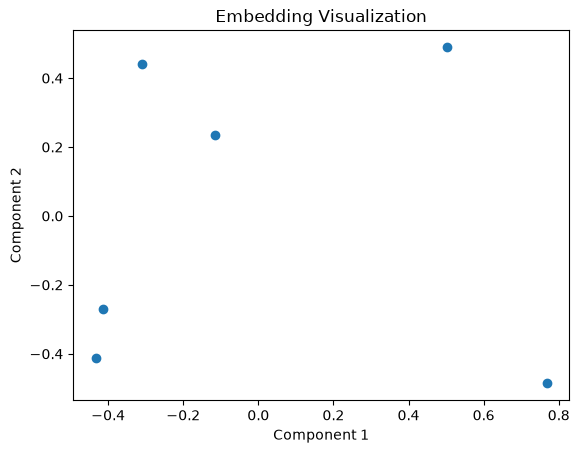

In [31]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

reduced = pca.fit_transform(doc_embeddings)

plt.scatter(
    reduced[:, 0],
    reduced[:, 1]
)

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Embedding Visualization")

plt.show()

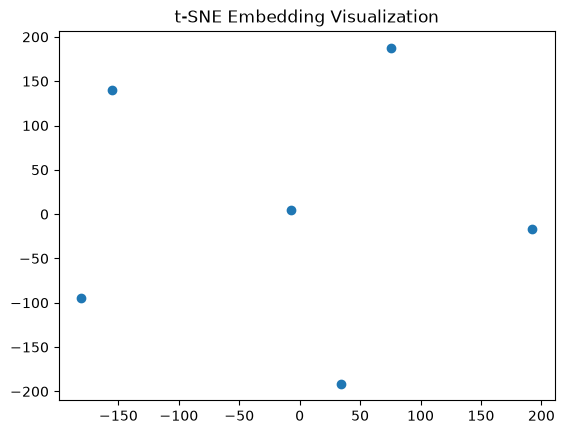

In [33]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=5
)

reduced = tsne.fit_transform(doc_embeddings)

plt.scatter(
    reduced[:, 0],
    reduced[:, 1]
)

plt.title("t-SNE Embedding Visualization")

plt.show()

In [41]:
texts = [
    "I love Python.",
    "Python is easy to learn.",
    "The weather is cold.",
    "hi ",
    "hi hello",
    "hi just",
    "hi cinay",
    "hi vinay"
]

embeddings = model.encode(texts)

print(embeddings.shape)

(8, 384)


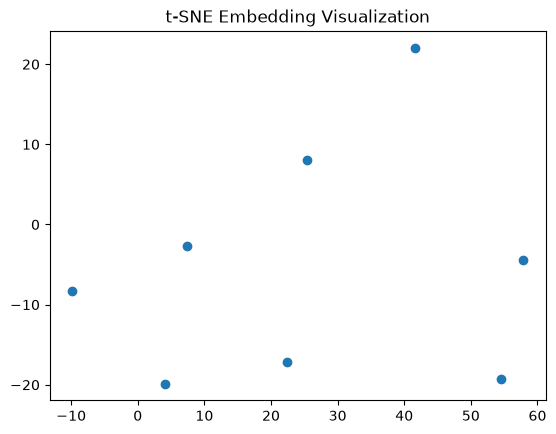

In [42]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=5
)

reduced = tsne.fit_transform(embeddings)

plt.scatter(
    reduced[:, 0],
    reduced[:, 1]
)

plt.title("t-SNE Embedding Visualization")

plt.show()

In [43]:
import umap.umap_ as umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(
    n_components=2,
    random_state=42
)

reduced = reducer.fit_transform(embeddings)

plt.scatter(
    reduced[:, 0],
    reduced[:, 1]
)

plt.title("UMAP Embedding Visualization")
plt.show()

ModuleNotFoundError: No module named 'umap'

In [44]:
sentences = [
    "Python is a programming language.",
    "Java is used for software development.",
    "JavaScript is used for web development.",
    
    "The football match was exciting.",
    "The cricket team won the game.",
    "The player scored a goal.",
    
    "The cat is sleeping.",
    "The dog is playing.",
    "The horse is running."
]

embeddings = model.encode(sentences)

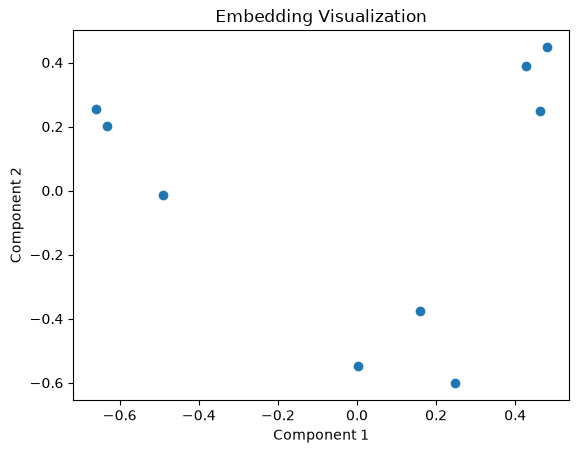

In [46]:
pca = PCA(n_components=2)

reduced = PCA(n_components=2).fit_transform(embeddings)

plt.scatter(
    reduced[:, 0],
    reduced[:, 1]
)

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Embedding Visualization")

plt.show()

In [ ]:
# above we can observe the clusters of similar data 

In [ ]:
# And for large of dfor mof data we need to manage make th efficinet storage 

# Ad if the large dat ahas the similar tyor of text we ca nmake the caching of the embeddings and vectors.

# so when we cache the dat ait first hts te cache memory before makaing t ne vectors of embeddings.